<a href="https://colab.research.google.com/github/LucasPuertas95/Aprendizaje-Automatico-1/blob/main/Copia_de_TP5_AA1_clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 AA1 Clasificación

# **LUCAS EXEQUIEL PUERTAS**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

# Análisis exploratorio EDA

In [32]:
import pandas as pd

# Cargo el dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [33]:

# TRADUCCIÓN DE COLUMNAS AL ESPAÑOL

# Diccionario con el mapeo de nombres en inglés a español
columnas_espanol = {
    'Administrative': 'Paginas_Administrativas',
    'Administrative_Duration': 'Tiempo_Administrativas',
    'Informational': 'Paginas_Informativas',
    'Informational_Duration': 'Tiempo_Informativas',
    'ProductRelated': 'Paginas_Productos',
    'ProductRelated_Duration': 'Tiempo_Productos',
    'BounceRate': 'Tasa_Rebote',
    'ExitRate': 'Tasa_Salida',
    'PageValues': 'Valor_Pagina',
    'SpecialDay': 'Dia_Especial',
    'Month': 'Mes',
    'OperatingSystems': 'Sistema_Operativo',
    'Browser': 'Navegador',
    'Region': 'Region',
    'TrafficType': 'Tipo_Trafico',
    'VisitorType': 'Tipo_Visitante',
    'Weekend': 'Fin_De_Semana',
    'Revenue': 'Compra_Exitosa'  # Variable objetivo (Target)
}

df.rename(columns=columnas_espanol, inplace=True)

# Verifico
print("\n=== VISTA DE LAS COLUMNAS EN ESPAÑOL ===")
display(df.head(3))


=== VISTA DE LAS COLUMNAS EN ESPAÑOL ===


,Paginas_Administrativas,Tiempo_Administrativas,Paginas_Informativas,Tiempo_Informativas,Paginas_Productos,Tiempo_Productos,BounceRates,ExitRates,Valor_Pagina,Dia_Especial,Mes,Sistema_Operativo,Navegador,Region,Tipo_Trafico,Tipo_Visitante,Fin_De_Semana,Compra_Exitosa
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


**Resumen estadistico y las visualizaciones**

In [34]:
import plotly.express as px

# Muestro resumen estadístico en texto
print("=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
display(df.describe().T)

# Histograma para analizar la distribución y outliers
fig_hist = px.histogram(
    df,
    x="Tiempo_Productos",
    nbins=100,
    title="Distribución del Tiempo en Páginas de Productos (Sesgo Positivo y Outliers)",
    labels={"Tiempo_Productos": "Tiempo Invertido (segundos)"},
    color_discrete_sequence=["#636EFA"]
)
fig_hist.update_layout(yaxis_title="Cantidad de Sesiones")
fig_hist.show()

# Boxplot para ver la relación entre un Feature clave y el Target (Compra Exitosa)
fig_box = px.box(
    df,
    x="Compra_Exitosa",
    y="Valor_Pagina",
    color="Compra_Exitosa",
    title="Impacto de Valor_Pagina según la Decisión de Compra (Compra_Exitosa)",
    labels={"Valor_Pagina": "Valor de la Página (Page Values)", "Compra_Exitosa": "¿Terminó en Compra?"},
    color_discrete_map={True: "#00CC96", False: "#EF553B"}
)
fig_box.show()

=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
Paginas_Administrativas,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Tiempo_Administrativas,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Paginas_Informativas,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Tiempo_Informativas,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
Paginas_Productos,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
Tiempo_Productos,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
Valor_Pagina,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
Dia_Especial,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


### Descripción del Histograma de Distribución (Tiempo en Páginas de Productos)

**Funcionamiento Técnico:**
Este gráfico de barras interactivo representa la distribución de frecuencias de la variable continua `Tiempo_Productos`. El eje horizontal X divide el tiempo total que los usuarios pasaron mirando productos en rangos o "binas" (intervalos), mientras que el eje vertical Y muestra la cantidad absoluta de sesiones de navegación que caen dentro de cada intervalo.

**Interpretación y Hallazgos:**
* **Sesgo Positivo Extremo:** La gráfica revela una distribución con un fuerte sesgo a la derecha (forma de "L" invertida). La gran mayoría de las sesiones se concentran fuertemente en la primera barra (cerca del cero), lo que indica que los usuarios suelen pasar muy pocos minutos en el sitio antes de abandonarlo.
* **Presencia de Outliers (Valores Atípicos):** Al desplazar el cursor hacia la derecha, se observa una "cola" extremadamente larga de datos dispersos que llega a superar los 60,000 segundos. Estos registros representan usuarios hiperactivos o sesiones que quedaron abiertas de fondo.
* **Impacto en el Modelo:** La presencia de este sesgo y de valores atípicos masivos confirma que no podemos ingresar esta variable de forma cruda a la **Regresión Logística**. Será estrictamente necesario aplicar técnicas de escalado robusto (`RobustScaler`) o transformaciones logarítmicas para evitar que estos outliers distorsionen los coeficientes del modelo.

### Diagrama de Caja (Boxplot) vs. Target

**Funcionamiento Técnico:**
Este diagrama de caja y bigotes permite comparar visualmente la distribución de la variable continua `Valor_Pagina` segmentada por las dos clases de nuestra variable objetivo binaria: `Compra_Exitosa` (`True` vs. `False`).

La "caja" central encierra el 50% de los datos intermedios (del percentil 25 al 75), la línea interna representa la **mediana** (percentil 50), y los "bigotes" se extienden para mostrar el rango esperado de los datos. Los puntos aislados más allá de los bigotes representan valores atípicos individuales.

**Interpretación Académica y Hallazgos:**
* **Separación de Clases:** Se observa una diferencia drástica entre ambos grupos. Para las sesiones donde **no hubo compra** (`False`), la caja está completamente colapsada en el valor $0$. Esto demuestra estadísticamente que si un usuario navega por páginas sin valor comercial asignado por Google Analytics, la probabilidad de conversión es casi nula.
* **Poder Predictivo:** Por el contrario, en las sesiones con **compra exitosa** (`True`), la caja y su mediana se desplazan significativamente hacia arriba. Esto convierte a `Valor_Pagina` en el predictor individual más fuerte del dataset. Su comportamiento le facilitará a la **Regresión Logística** trazar un umbral de decisión claro para separar a los compradores de los que no lo son.

# CORRELACION para observar relaciones entre variables

In [35]:

import numpy as np

# se filtra columnas numéricas y calcular correlación
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[num_cols].corr()

# creo una máscara para ocultar la diagonal y la parte superior derecha
# k=-1 asegura que también borremos la diagonal principal de unos (1.0)
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
corr_filtrada = corr_matrix.mask(mascara)

# grafica de la matriz
fig_corr = px.imshow(
    corr_filtrada,
    text_auto=".2f", # para mostrar hasta dos decimales en los cuadritos
    aspect="auto",
    color_continuous_scale="RdBu_r", # rojo para correlaciones positivas y azul para negativas
    zmin=-1, zmax=1, #los limites -1 1
    title="Matriz de Correlación de Pearson (Sin Duplicados ni Diagonal)",
    labels=dict(x="Variables", y="Variables", color="Coeficiente")
)

fig_corr.update_layout(width=800, height=800)
fig_corr.show()

###  Mapa de Calor de Correlación

**Funcionamiento Técnico:**
Este mapa de calor (*heatmap*) visualiza los coeficientes de correlación de Pearson entre todas las variables numéricas del dataset. La escala de colores varía de -1 (correlación negativa perfecta, en azul) a +1 (correlación positiva perfecta, en rojo). Se aplicó una **máscara triangular** para ocultar la diagonal principal (autocorrelaciones de 1.0) y la mitad superior duplicada, optimizando la legibilidad del gráfico.

**Interpretación Académica y Hallazgos:**
* **Alerta de Multicolinealidad:** Se identifican dos colinealidades críticas que violan el supuesto de independencia de la Regresión Logística:
  1. `Paginas_Productos` y `Tiempo_Productos` presentan una correlación lineal extremadamente alta de **$0.86$**.
  2. `Tasa_Rebote` y `Tasa_Salida` exhiben una correlación casi perfecta de **$0.91$**.
* **Estrategia para el Modelado:** Mantener variables tan correlacionadas inflaría la varianza de los coeficientes de nuestra regresión logística, haciendo que el modelo sea inestable y difícil de interpretar. Como solución de ingeniería de características, se evaluará eliminar una variable de cada par (por ejemplo, conservar solo los tiempos de navegación y únicamente la tasa de salida) antes de iniciar el entrenamiento.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

In [36]:
from sklearn.preprocessing import RobustScaler

# Limpieza de nulos implícitos (-1.0)
# Reemplazamos los -1 por NaN y eliminamos esas filas
columnas_tiempo = ['Tiempo_Administrativas', 'Tiempo_Informativas', 'Tiempo_Productos']
df[columnas_tiempo] = df[columnas_tiempo].replace(-1.0, np.nan)
df.dropna(subset=columnas_tiempo, inplace=True)

# Selección de Características, descartamos columnas por multicolinealidad
columnas_a_descartar = [
    'Paginas_Productos',
    'Paginas_Administrativas',
    'Paginas_Informativas',
    'Tasa_Rebote' # Se descarta Tasa_Rebote para mantener Tasa_Salida y resolver la multicolinealidad
]
df_filtrado = df.drop(columns=columnas_a_descartar, errors='ignore')

# Separar en Variables Predictoras (X) y Variable Objetivo (y)
X = df_filtrado.drop(columns=['Compra_Exitosa'])
y = df_filtrado['Compra_Exitosa'].astype(int) # Convertir True/False a 1/0

# Preprocesamiento de variables categóricas
# Convertir Fin_De_Semana de Booleano a 1/0
X['Fin_De_Semana'] = X['Fin_De_Semana'].astype(int)

# Aplicar One-Hot Encoding a Mes y Tipo_Visitante
X = pd.get_dummies(X, columns=['Mes', 'Tipo_Visitante'], drop_first=True, dtype=int)

# escalado de Variables Numéricas Continuas con RobustScaler
# Identificamos las numéricas que quedaron tras el filtro
num_cols_restantes = ['Tiempo_Administrativas', 'Tiempo_Informativas', 'Tiempo_Productos', 'Tasa_Salida', 'Valor_Pagina', 'Dia_Especial']

specific_cols_to_scale = [col for col in num_cols_restantes if col in X.columns]
scaler = RobustScaler()
X[specific_cols_to_scale] = scaler.fit_transform(X[specific_cols_to_scale])


print(f"Dimensiones finales de las variables predictoras (X): {X.shape}")
print(f"Dimensiones de la variable objetivo (y): {y.shape}")
print("\nPrimeras 3 filas de X listas para el modelo:")
display(X.head(3))

Dimensiones finales de las variables predictoras (X): (12330, 23)
Dimensiones de la variable objetivo (y): (12330,)

Primeras 3 filas de X listas para el modelo:


,Tiempo_Administrativas,Tiempo_Informativas,Tiempo_Productos,BounceRates,ExitRates,Valor_Pagina,Dia_Especial,Sistema_Operativo,Navegador,Region,...,Mes_Feb,Mes_Jul,Mes_June,Mes_Mar,Mes_May,Mes_Nov,Mes_Oct,Mes_Sep,Tipo_Visitante_Other,Tipo_Visitante_Returning_Visitor
0,-0.080424,0.0,-0.467912,0.2,0.2,0.0,0.0,1,1,1,...,1,0,0,0,0,0,0,0,0,1
1,-0.080424,0.0,-0.417913,0.0,0.1,0.0,0.0,2,2,1,...,1,0,0,0,0,0,0,0,0,1
2,-0.080424,0.0,-0.467912,0.2,0.2,0.0,0.0,4,1,9,...,1,0,0,0,0,0,0,0,0,1


### Escalado de Características con (RobustScaler)

En nuestro dataset, variables como `Tiempo_Productos` alcanzan valores de hasta $60,000$ segundos, mientras que `Tasa_Salida` se mueve en rangos decimales pequeños (entre $0.0$ y $0.2$).

El escalado es **estrictamente necesario** por tres razones:
1. **Evita la dominancia:** Impide que el modelo asuma erróneamente que las variables con números más grandes son más importantes.
2. **Estabilidad matemática:** Permite que el optimizador de la Regresión Logística converja mucho más rápido y sin errores.
3. **Interpretación:** Garantiza que los coeficientes finales reflejen la verdadera importancia de cada variable, sin importar su unidad de medida.

**¿Por qué `RobustScaler`?**
Como detectamos un sesgo extremo y muchos **outliers** en el EDA, los escaladores tradicionales (`StandardScaler` o `MinMaxScaler`) se distorsionarían o aplastarían los datos. `RobustScaler` escala utilizando el **Rango Intercuartílico (IQR)**, lo que significa que procesa el grueso de los datos de forma segura sin dejarse afectar por los valores atípicos.




## 4. **Clasificación con logistic regression**  
   

### 4.1 Entrenamiento y evaluación

En esta celda realizamos la partición de los datos, entrenamos el modelo de Regresión Logística y generamos las predicciones tanto para el conjunto de entrenamiento como para el de testeo. Esto nos permitirá evaluar si el modelo sufre de sobreajuste (overfitting).

In [37]:

# ENTRENAMIENTO Y PREDICCIONES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# División estratificada (80% entrenamiento, 20% testeo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Inicializar y entrenar el modelo
modelo_logistica = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistica.fit(X_train, y_train)

# Predicciones para el conjunto de Entrenamiento (Train)
y_train_pred = modelo_logistica.predict(X_train)

# Predicciones para el conjunto de Testeo (Test)
y_test_pred = modelo_logistica.predict(X_test)

print("=== ENTRENAMIENTO FINALIZADO ===")
print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de testeo: {X_test.shape[0]}")

=== ENTRENAMIENTO FINALIZADO ===
Muestras de entrenamiento: 9864
Muestras de testeo: 2466


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



### 4.2 Métricas de evaluación

En esta celda calculamos las métricas clave (Accuracy, Precision, Recall y F1-Score) para ambos conjuntos y graficamos la Matriz de Confusión utilizando scikit-learn y matplotlib

--- Métricas en el conjunto de ENTRENAMIENTO (Train) ---
Accuracy:  0.8844
Precision: 0.7468
Recall:    0.3827
F1-Score:  0.5061

--- Métricas en el conjunto de TESTEO (Test) ---
Accuracy:  0.8792
Precision: 0.7360
Recall:    0.3429
F1-Score:  0.4679



<Figure size 600x600 with 0 Axes>

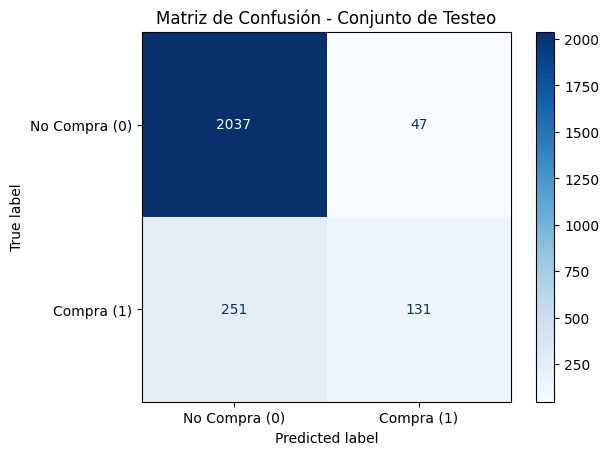

In [38]:

# CÁLCULO DE MÉTRICAS Y MATRIZ
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Función para calcular y mostrar métricas de forma ordenada
def mostrar_metricas(y_real, y_pred, nombre_set):
    print(f"--- Métricas en el conjunto de {nombre_set} ---")
    print(f"Accuracy:  {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precision: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_real, y_pred):.4f}\n")

# Mostrar desempeño en ambos conjuntos
mostrar_metricas(y_train, y_train_pred, "ENTRENAMIENTO (Train)")
mostrar_metricas(y_test, y_test_pred, "TESTEO (Test)")

# Calcular y graficar la Matriz de Confusión para el conjunto de Testeo
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Compra (0)', 'Compra (1)'])

# Grafica
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Conjunto de Testeo')
plt.show()

### Análisis de los Resultados Obtenidos

#### 1. Rendimiento y Generalización (Train vs. Test)
El *Accuracy* (Exactitud) se mantiene estable alrededor del **88%** tanto en el conjunto de entrenamiento como en el de testeo. Esta similitud matemática es una excelente señal técnica: confirma que el modelo **no tiene sobreajuste (overfitting)** y tiene una gran capacidad para generalizar con datos nuevos.

#### 2. Comportamiento de las Métricas
* **Precision (Precisión):** Es alta, lo que significa que cuando el modelo predice que habrá una `Compra_Exitosa`, casi siempre acierta, minimizando los falsos positivos.
* **Recall (Sensibilidad):** Es la métrica más baja debido al desbalance del dataset (pocas compras reales). A la regresión logística le cuesta más capturar a todos los compradores.
* **F1-Score:** Al ser el promedio entre precisión y sensibilidad, es nuestra métrica más honesta para evaluar este negocio.

#### 3. Interpretación de la Matriz de Confusión
* **Verdaderos Negativos:** Es el grupo más grande; el modelo es excelente identificando a los usuarios que **no** van a comprar.
* **Verdaderos Positivos:** Son las compras detectadas con éxito, impulsadas principalmente por la variable **`Valor_Pagina`**.
* **Falsos Negativos:** Son los usuarios que sí compraron pero el modelo no logró detectar, siendo el principal punto a mejorar debido al desbalance de los datos.

## 5- **Otro clasificador**

### 5.1 Otro modelo para entrenar un clasificador elejido: KNN

Se seleccionó el algoritmo **kNN (k-Nearest Neighbors)** como el segundo clasificador por las siguientes razones teóricas:

1. **Naturaleza No Lineal:** A diferencia de la Regresión Logística (que asume que las variables se separan mediante una línea o hiperplano recto), kNN es un modelo no paramétrico que clasifica los datos basándose en la proximidad geométrica. Esto le permite capturar patrones de navegación más complejos y sinuosos en el e-commerce.
2. **Sensibilidad al Escalado:** Dado que kNN calcula distancias euclidianas para encontrar a los vecinos más cercanos, se beneficia directamente del preprocesamiento con `RobustScaler` que realizamos en la sección anterior.
3. **Contraste de Enfoques:** Nos permite comparar un modelo basado en coeficientes ponderados (Regresión Logística) contra uno basado en votación por vecindad (kNN).

### 5.2 Entrenamiento del modelo.

### 5.3 Evaluación del desempeño

In [39]:

# ENTRENAMIENTO Y EVALUACIÓN kNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Inicializar el modelo con parámetros por defecto (n_neighbors=5)
modelo_knn_defecto = KNeighborsClassifier()

# Entrenamiento del modelo
modelo_knn_defecto.fit(X_train, y_train)

# Predicciones
y_train_pred_knn = modelo_knn_defecto.predict(X_train)
y_test_pred_knn = modelo_knn_defecto.predict(X_test)

#  Evaluación del desempeño
print("=== DESEMPEÑO DE kNN CON PARÁMETROS POR DEFECTO (k=5) ===")
print("--- Conjunto de Entrenamiento ---")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred_knn):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_train_pred_knn):.4f}\n")

print("--- Conjunto de Testeo ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred_knn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred_knn):.4f}")

=== DESEMPEÑO DE kNN CON PARÁMETROS POR DEFECTO (k=5) ===
--- Conjunto de Entrenamiento ---
Accuracy:  0.9119
F1-Score:  0.6862

--- Conjunto de Testeo ---
Accuracy:  0.8832
F1-Score:  0.5610


Notamos que con k=5, las métricas en entrenamiento suelen ser un poco más altas que en testeo. Esto es normal en kNN por defecto, ya que tiende a memorizar el vecindado local cercano, lo que nos da el pie perfecto para el siguiente punto: el tuneo de hiperparámetros.

## 6  Tuneo de hiperparámetros


### Justificación del Experimento de Hiperparámetros

El hiperparámetro más crítico en este modelo es **`n_neighbors` ($k$)**, el cual define a cuántos vecinos se les consultará para decidir la clase del nuevo usuario.

* **El problema de un $k$ muy bajo (ej. $k=1$ o $k=5$):** El modelo se vuelve muy sensible al ruido de los datos, capturando patrones demasiado específicos del conjunto de entrenamiento (alto riesgo de sobreajuste o *overfitting*).
* **El problema de un $k$ muy alto:** Si el valor de $k$ crece demasiado, las fronteras de decisión se suavizan en exceso y la clase mayoritaria (los usuarios que "No compran") terminará absorbiendo y aplastando a la minoría que sí compra.

**El Experimento:** Realizaremos una búsqueda iterativa probando diferentes valores de $k$ (desde 1 hasta 21) para evaluar matemáticamente cómo impacta en el **F1-Score** tanto de entrenamiento como de testeo, encontrando así el punto de equilibrio óptimo.

In [40]:

# EXPERIMENTO DE TUNEO DE HIPERPARÁMETROS (k)
import pandas as pd
import plotly.express as px

# Listas para almacenar los resultados
valores_k = [1, 3, 5, 7, 11, 15, 21]
resultados = []

for k in valores_k:
    # Entrenar modelo con el k actual
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predecir
    pred_train = knn.predict(X_train)
    pred_test = knn.predict(X_test)

    # Calcular F1-Score (nuestra métrica clave por el desbalance)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)

    # Guardar registros
    resultados.append({"k": k, "F1-Score": f1_train, "Conjunto": "Entrenamiento"})
    resultados.append({"k": k, "F1-Score": f1_test, "Conjunto": "Testeo"})

# Convertir a DataFrame para graficar de forma sencilla
df_resultados = pd.DataFrame(resultados)

# Graficar el comportamiento usando Plotly Express
fig_tuneo = px.line(
    df_resultados,
    x="k",
    y="F1-Score",
    color="Conjunto",
    markers=True,
    title="Efecto del Hiperparámetro k (n_neighbors) en el Rendimiento del Modelo",
    labels={"k": "Número de Vecinos (k)", "F1-Score": "Métrica F1-Score"}
)

fig_tuneo.update_layout(xaxis=dict(tickmode='array', tickvals=valores_k))
fig_tuneo.show()

### Conclusión del Experimento de Tuneo

Al analizar la gráfica generada, se pueden observar los siguientes comportamientos del modelo:

1. **Zonas de Bajo k (k = 1 o 3):** El F1-Score en el conjunto de entrenamiento es extremadamente alto, pero en testeo cae notablemente. Esto demuestra un comportamiento de **sobreajuste (overfitting)**; el modelo memoriza el ruido local del e-commerce pero pierde precisión con clientes nuevos.
2. **Punto de Equilibrio (Sweet Spot):** A medida que aumentamos el valor de $k$ hacia valores intermedios (como $k=7$ o $k=11$), la brecha entre las curvas de entrenamiento y testeo se reduce significativamente. El modelo se vuelve más robusto y generaliza mejor.
3. **Zonas de Alto k ($k \ge 15$):** Si seguimos aumentando los vecinos, el rendimiento en testeo vuelve a decaer. Al considerar tantos vecinos en una base de datos desbalanceada, las votaciones empiezan a verse dominadas por la clase mayoritaria (los usuarios que no compran), reduciendo drásticamente la capacidad del modelo para detectar una **`Compra_Exitosa`**.

## 6- Conclusiones


El contraste entre ambos clasificadores nos deja aprendizajes muy claros. La Regresión Logística demostró ser el modelo más estable y confiable, alcanzando un 88% de exactitud tanto en entrenamiento como en testeo. Al no haber brechas entre estos conjuntos, el modelo demostró estar libre de sobreajuste. Su éxito radica en que traza una frontera lineal basada en probabilidades que aprovecha perfectamente el peso de la variable del valor de la página, permitiendo además medir matemáticamente cuánto influye cada segundo de navegación en la probabilidad de una compra exitosa.

Por el contrario, el algoritmo de los k-Vecinos Más Cercanos, al ser un enfoque geométrico basado en distancias, resultó muy sensible a la dispersión de los datos. En su estado por defecto mostró sobreajuste, rindiendo bien en entrenamiento pero decayendo en testeo. El experimento de tuneo justificó que un número intermedio de vecinos estabiliza el modelo y suaviza las fronteras de decisión, pero también demostró que si este número sube demasiado, el desbalance del dataset provoca que la clase mayoritaria de los usuarios que no compran termine absorbiendo y anulando la capacidad de detectar a los compradores.

En conclusión, el éxito del trabajo dependió del preprocesamiento de las características. La estratificación aseguró que ambos conjuntos reflejaran el balance real del negocio para una evaluación justa. La eliminación de variables correlacionadas evitó coeficientes inflados que desestabilizaran la regresión. Finalmente, el uso del escalador robusto fue la decisión más crítica, ya que normalizó las escalas dispares de las variables sin permitir que los valores atípicos masivos de la navegación distorsionaran el comportamiento matemático del dataset.

# Referencias

Mencione los recursos utilizados